# DLS FR Spring 2026 — ArcFace remaster on the legacy Fall 2025 same-identity dataset

This notebook keeps the **Spring 2026 ArcFace model, loss, margin schedule, training loop, checkpoints, diagnostics, and reporting**, but replaces the 21k manifest-backed input pipeline with the legacy Fall 2025 `ImageFolder` dataset.

Expected legacy dataset layout:

```text
DATA_ROOT/
  train/images/<identity>/*.jpg
  val/images/<identity>/*.jpg
  test/images/<identity>/*.jpg
```

The same identity set must be present in `train`, `val`, and `test`.

## Evaluation protocol

- **Optimization train:** all images from `train/images`.
- **Same-identity validation:** the pre-existing `val/images` split; no image is removed from training by this notebook.
- **Independent same-identity retrieval/test:** the pre-existing `test/images` split, evaluated by normalized embedding retrieval and verification metrics.

This is intentionally different from the 21k Spring 2026 notebook, where one image per train identity was held out virtually. Here the old dataset split is used exactly as exported, so identities can have substantially more optimization examples.

**Important:** this notebook does not assume a hard-coded number of images per identity. It prints per-split identity-count statistics at startup so the actual legacy export can be verified directly.

## Cell 1 — Imports


In [2]:
import os
import json
import time
import math
import random
import platform
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

print("[sanity] torch:", torch.__version__)
print("[sanity] torchvision:", torchvision.__version__)


[sanity] torch: 2.9.1
[sanity] torchvision: 0.24.1


## Cell 2 — Device detection


In [3]:
def pick_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = pick_device()

# macOS/Jupyter multiprocessing with notebook-defined Dataset classes is fragile.
# CUDA/Colab can safely use several loader workers.
NUM_WORKERS = 4 if device.type == "cuda" else 0
PIN_MEMORY = device.type == "cuda"

if device.type == "cuda":
    torch.backends.cudnn.benchmark = False

print("[sanity] device:", device)
print("[sanity] num_workers:", NUM_WORKERS)
print("[sanity] pin_memory:", PIN_MEMORY)


[sanity] device: mps
[sanity] num_workers: 0
[sanity] pin_memory: False


## Cell 3 — Config


In [4]:
# ============================================================
# EDIT ONLY DATA_ROOT IF THE LEGACY DATASET MOVES
# ============================================================

# Legacy Fall 2025 ImageFolder dataset.
# Expected structure:
#   DATA_ROOT/train/images/<identity>/*.jpg
#   DATA_ROOT/val/images/<identity>/*.jpg
#   DATA_ROOT/test/images/<identity>/*.jpg

OLD_ROOT = Path("/Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2025.1.1осень/10_PROj")
DATA_ROOT = OLD_ROOT / "celeba_wild_aligned_112_splits_20"

SEED = 42

IMG_SIZE = 112
BATCH_SIZE = 128

EPOCHS = 21
REFERENCE_EPOCH = 15

LR = 3e-4
WEIGHT_DECAY = 1e-4

BACKBONE = "resnet18"
PRETRAINED = True

MARGIN_M = 0.25
SCALE_S = 64.0
M_WARMUP_EPOCHS = 5
M_RAMP_END_EPOCH = 10

USE_RANDOM_HFLIP = True
USE_COLORJITTER = False

BEST_CHECKPOINT_METRIC = "sameid_val_arcface_loss"
RETRIEVAL_TEST_METRIC = "leave_one_out_cosine_rank1"

MARGIN_TAG = f"m{MARGIN_M:.2f}".replace(".", "p")
RUN_NAME = (
    f"arcface_resnet18_legacyFall2025"
    f"_sameidval"
    f"_ep{EPOCHS}"
    f"_ref{REFERENCE_EPOCH}"
    f"_fr{M_RAMP_END_EPOCH}"
    f"_{MARGIN_TAG}"
)

THE_ROOT = Path("/Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject")
FRONTEND_ROOT = THE_ROOT / "Pipeline_stage/0_align_block_for/out/celeba_wild_21k_frontend_v0_1"
RUN_DIR = FRONTEND_ROOT / "_recognition_runs" / RUN_NAME
RUN_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# Startup sanity
# ============================================================
assert DATA_ROOT.exists(), f"DATA_ROOT not found: {DATA_ROOT}"
for split in ["train", "val", "test"]:
    p = DATA_ROOT / split / "images"
    assert p.exists(), f"Missing legacy dataset directory: {p}"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("[sanity] DATA_ROOT:", DATA_ROOT)
print("[sanity] RUN_NAME:", RUN_NAME)
print("[sanity] RUN_DIR:", RUN_DIR)
print("[sanity] backbone:", BACKBONE, "| pretrained:", PRETRAINED)
print("[sanity] ArcFace m,s:", MARGIN_M, SCALE_S, "| warmup:", M_WARMUP_EPOCHS)
print("[sanity] training epochs:", EPOCHS, "| fixed reference epoch:", REFERENCE_EPOCH)
print("[sanity] same-ID validation source: DATA_ROOT/val/images")
print("[sanity] retrieval/test source: DATA_ROOT/test/images")
print("[sanity] best checkpoint metric:", BEST_CHECKPOINT_METRIC)

[sanity] DATA_ROOT: /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2025.1.1осень/10_PROj/celeba_wild_aligned_112_splits_20
[sanity] RUN_NAME: arcface_resnet18_legacyFall2025_sameidval_ep21_ref15_fr10_m0p25
[sanity] RUN_DIR: /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/0_align_block_for/out/celeba_wild_21k_frontend_v0_1/_recognition_runs/arcface_resnet18_legacyFall2025_sameidval_ep21_ref15_fr10_m0p25
[sanity] backbone: resnet18 | pretrained: True
[sanity] ArcFace m,s: 0.25 64.0 | warmup: 5
[sanity] training epochs: 21 | fixed reference epoch: 15
[sanity] same-ID validation source: DATA_ROOT/val/images
[sanity] retrieval/test source: DATA_ROOT/test/images
[sanity] best checkpoint metric: sameid_val_arcface_loss


## Cell 4 — Load final selection and normalize split names


In [5]:
# ============================================================
# Legacy Fall 2025 ImageFolder contract
# ============================================================

# Use ImageFolder only to discover files/classes. The actual training datasets
# below remain ManifestFaceDataset instances so the Spring 2026 training code
# can stay unchanged.
legacy_train_index = ImageFolder(DATA_ROOT / "train" / "images")
legacy_val_index   = ImageFolder(DATA_ROOT / "val" / "images")
legacy_test_index  = ImageFolder(DATA_ROOT / "test" / "images")

assert legacy_train_index.classes == legacy_val_index.classes == legacy_test_index.classes, (
    "Legacy train/val/test must contain exactly the same identity folders."
)
assert legacy_train_index.class_to_idx == legacy_val_index.class_to_idx == legacy_test_index.class_to_idx

identity_to_class = dict(legacy_train_index.class_to_idx)
num_classes = len(identity_to_class)


def imagefolder_to_table(ds: ImageFolder, split_name: str) -> pd.DataFrame:
    idx_to_class = {idx: name for name, idx in ds.class_to_idx.items()}
    rows = []
    for path_str, class_idx in ds.samples:
        path = Path(path_str)
        rows.append({
            "filename": path.name,
            "identity_id": str(idx_to_class[int(class_idx)]),
            "class_idx": int(class_idx),
            "subset": split_name,
            "resolved_path": str(path.resolve()),
        })
    return pd.DataFrame(rows)


train_df = imagefolder_to_table(legacy_train_index, "train")
sameid_val_df = imagefolder_to_table(legacy_val_index, "val")
retrieval_test_df = imagefolder_to_table(legacy_test_index, "test")

assert len(train_df) > 0 and len(sameid_val_df) > 0 and len(retrieval_test_df) > 0
assert train_df["class_idx"].nunique() == num_classes
assert sameid_val_df["class_idx"].nunique() == num_classes
assert retrieval_test_df["class_idx"].nunique() == num_classes

# Check that files are physically separate across the exported splits.
train_paths = set(train_df["resolved_path"])
val_paths = set(sameid_val_df["resolved_path"])
test_paths = set(retrieval_test_df["resolved_path"])
assert train_paths.isdisjoint(val_paths)
assert train_paths.isdisjoint(test_paths)
assert val_paths.isdisjoint(test_paths)

# Persist exact class mapping used by the ArcFace head.
mapping_df = pd.DataFrame({
    "identity_id": legacy_train_index.classes,
    "class_idx": [identity_to_class[x] for x in legacy_train_index.classes],
})
mapping_path = RUN_DIR / "identity_to_class.csv"
mapping_df.to_csv(mapping_path, index=False)

# Persist a single manifest for reproducibility without copying images.
legacy_manifest = pd.concat(
    [train_df, sameid_val_df, retrieval_test_df],
    ignore_index=True,
).sort_values(["subset", "identity_id", "filename"]).reset_index(drop=True)
manifest_path = RUN_DIR / "legacy_dataset_manifest.csv"
legacy_manifest.to_csv(manifest_path, index=False)


def describe_identity_counts(table: pd.DataFrame, name: str):
    counts = table.groupby("identity_id").size()
    print(
        f"[sanity] {name}: images={len(table)} identities={counts.size} | "
        f"images/id min={int(counts.min())} median={float(counts.median()):.1f} "
        f"mean={float(counts.mean()):.2f} max={int(counts.max())}"
    )
    return counts

train_counts = describe_identity_counts(train_df, "train")
val_counts = describe_identity_counts(sameid_val_df, "val same-ID")
test_counts = describe_identity_counts(retrieval_test_df, "test same-ID")

print("[sanity] num classifier classes:", num_classes)
print("[OK] identical identity/class mapping across train/val/test")
print("[OK] saved:", mapping_path)
print("[OK] saved:", manifest_path)

[sanity] train: images=13271 identities=666 | images/id min=16 median=20.0 mean=19.93 max=20
[sanity] val same-ID: images=1329 identities=666 | images/id min=1 median=2.0 mean=2.00 max=2
[sanity] test same-ID: images=1330 identities=666 | images/id min=1 median=2.0 mean=2.00 max=2
[sanity] num classifier classes: 666
[OK] identical identity/class mapping across train/val/test
[OK] saved: /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/0_align_block_for/out/celeba_wild_21k_frontend_v0_1/_recognition_runs/arcface_resnet18_legacyFall2025_sameidval_ep21_ref15_fr10_m0p25/identity_to_class.csv
[OK] saved: /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/0_align_block_for/out/celeba_wild_21k_frontend_v0_1/_recognition_runs/arcface_resnet18_legacyFall2025_sameidval_ep21_ref15_fr10_m0p25/legacy_dataset_manifest.csv


## Cell 5 — Resolve paths and assert the frozen 21k contract


In [7]:
# ============================================================
# Legacy split contract checks
# ============================================================

train_ids = set(train_df["identity_id"])
val_ids = set(sameid_val_df["identity_id"])
test_ids = set(retrieval_test_df["identity_id"])

assert train_ids == val_ids == test_ids, (
    "Expected same identities in legacy train/val/test splits. "
    f"train={len(train_ids)}, val={len(val_ids)}, test={len(test_ids)}"
)

# Every class must have at least one training image and one validation image.
assert (train_df.groupby("identity_id").size() >= 1).all()
assert (sameid_val_df.groupby("identity_id").size() >= 1).all()

# Retrieval metrics need at least two test images per identity to create genuine pairs
# and meaningful leave-one-out nearest-neighbour matches.
test_per_id = retrieval_test_df.groupby("identity_id").size()
if (test_per_id < 2).any():
    bad = test_per_id[test_per_id < 2]
    print(
        "[warning] Some test identities have <2 images; retrieval Rank-1/verification "
        "will be less informative for those identities. Examples:",
        bad.head(10).to_dict(),
    )
else:
    print("[OK] every test identity has at least 2 images for retrieval/verification")

print("[OK] legacy same-identity split contract passed")

[warning] Some test identities have <2 images; retrieval Rank-1/verification will be less informative for those identities. Examples: {'8714': 1, '9698': 1}
[OK] legacy same-identity split contract passed


## Cell 6 — Train-only contiguous class mapping


In [8]:
# ============================================================
# Pre-defined same-identity splits from the legacy Fall 2025 export
# ============================================================
# No virtual holdout is created here.
# All legacy train images remain optimization images.
# Legacy val is the honest same-identity classification validation set.
# Legacy test is reserved for independent same-identity retrieval/verification.

split_summary = {
    "seed": int(SEED),
    "source": "legacy Fall 2025 ImageFolder export",
    "train_images": int(len(train_df)),
    "validation_images": int(len(sameid_val_df)),
    "test_images": int(len(retrieval_test_df)),
    "num_identities": int(num_classes),
    "identity_sets_equal_train_val_test": bool(
        set(train_df["identity_id"]) == set(sameid_val_df["identity_id"]) == set(retrieval_test_df["identity_id"])
    ),
    "virtual_train_holdout_used": False,
    "source_files_modified_or_copied": False,
    "train_images_per_identity": {
        "min": int(train_counts.min()),
        "median": float(train_counts.median()),
        "mean": float(train_counts.mean()),
        "max": int(train_counts.max()),
    },
    "val_images_per_identity": {
        "min": int(val_counts.min()),
        "median": float(val_counts.median()),
        "mean": float(val_counts.mean()),
        "max": int(val_counts.max()),
    },
    "test_images_per_identity": {
        "min": int(test_counts.min()),
        "median": float(test_counts.median()),
        "mean": float(test_counts.mean()),
        "max": int(test_counts.max()),
    },
}

split_summary_path = RUN_DIR / "legacy_split_summary.json"
split_summary_path.write_text(json.dumps(split_summary, indent=2))

print(json.dumps(split_summary, indent=2))
print("[OK] saved:", split_summary_path)

{
  "seed": 42,
  "source": "legacy Fall 2025 ImageFolder export",
  "train_images": 13271,
  "validation_images": 1329,
  "test_images": 1330,
  "num_identities": 666,
  "identity_sets_equal_train_val_test": true,
  "virtual_train_holdout_used": false,
  "source_files_modified_or_copied": false,
  "train_images_per_identity": {
    "min": 16,
    "median": 20.0,
    "mean": 19.926426426426428,
    "max": 20
  },
  "val_images_per_identity": {
    "min": 1,
    "median": 2.0,
    "mean": 1.9954954954954955,
    "max": 2
  },
  "test_images_per_identity": {
    "min": 1,
    "median": 2.0,
    "mean": 1.996996996996997,
    "max": 2
  }
}
[OK] saved: /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/0_align_block_for/out/celeba_wild_21k_frontend_v0_1/_recognition_runs/arcface_resnet18_legacyFall2025_sameidval_ep21_ref15_fr10_m0p25/legacy_split_summary.json


## Cell 7 — Recognition transforms


In [9]:
# Exact CE preprocessing contract for controlled CE-vs-ArcFace comparison.
train_tfms = [
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
]
if USE_RANDOM_HFLIP:
    train_tfms.insert(1, transforms.RandomHorizontalFlip(p=0.5))
if USE_COLORJITTER:
    train_tfms.insert(
        1,
        transforms.ColorJitter(
            brightness=0.2,
            contrast=0.2,
            saturation=0.2,
            hue=0.02,
        ),
    )

train_tfm = transforms.Compose(train_tfms)

eval_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

print("[sanity] transforms ready")


[sanity] transforms ready


## Cell 8 — Manifest-backed datasets


In [10]:
class ManifestFaceDataset(Dataset):
    def __init__(self, table: pd.DataFrame, transform, classification: bool):
        self.table = table.reset_index(drop=True).copy()
        self.transform = transform
        self.classification = bool(classification)

        required = {"resolved_path", "identity_id"}
        if self.classification:
            required.add("class_idx")

        missing = required - set(self.table.columns)
        if missing:
            raise ValueError(f"Dataset table missing columns: {sorted(missing)}")

    def __len__(self):
        return len(self.table)

    def __getitem__(self, idx):
        row = self.table.iloc[idx]
        path = Path(row["resolved_path"])

        with Image.open(path) as im:
            image = im.convert("RGB")

        image = self.transform(image)

        if self.classification:
            return image, int(row["class_idx"])

        return image, str(row["identity_id"])


# Optimization train: augmentation enabled.
ds_train = ManifestFaceDataset(
    train_df,
    train_tfm,
    classification=True,
)

# Same-identity validation: same classifier classes, but deterministic eval transforms.
ds_val_sameid = ManifestFaceDataset(
    sameid_val_df,
    eval_tfm,
    classification=True,
)

# Independent legacy test retrieval: same identities as train, labels are identity strings.
ds_test_retrieval = ManifestFaceDataset(
    retrieval_test_df,
    eval_tfm,
    classification=False,
)

print("[sanity] dataset sizes:", {
    "train_optimization": len(ds_train),
    "validation_same_identity": len(ds_val_sameid),
    "test_same_identity_retrieval": len(ds_test_retrieval),
})

x0, y0 = ds_train[0]
assert x0.shape == (3, IMG_SIZE, IMG_SIZE)
assert 0 <= y0 < num_classes

xv, yv = ds_val_sameid[0]
assert xv.shape == (3, IMG_SIZE, IMG_SIZE)
assert 0 <= yv < num_classes

xd, idd = ds_test_retrieval[0]

print("[sanity] train sample:", x0.shape, x0.dtype, y0)
print("[sanity] same-ID val sample:", xv.shape, xv.dtype, yv)
print("[sanity] retrieval test sample:", xd.shape, "| identity_id:", idd)


[sanity] dataset sizes: {'train_optimization': 13271, 'validation_same_identity': 1329, 'test_same_identity_retrieval': 1330}
[sanity] train sample: torch.Size([3, 112, 112]) torch.float32 0
[sanity] same-ID val sample: torch.Size([3, 112, 112]) torch.float32 0
[sanity] retrieval test sample: torch.Size([3, 112, 112]) | identity_id: 10023


## Cell 9 — DataLoaders


In [11]:
loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
if NUM_WORKERS > 0:
    loader_kwargs["persistent_workers"] = True

dl_train = DataLoader(
    ds_train,
    shuffle=True,
    **loader_kwargs,
)

dl_val_sameid = DataLoader(
    ds_val_sameid,
    shuffle=False,
    **loader_kwargs,
)

dl_test_retrieval = DataLoader(
    ds_test_retrieval,
    shuffle=False,
    **loader_kwargs,
)

xb, yb = next(iter(dl_train))
xv, yv = next(iter(dl_val_sameid))

print("[sanity] train batch shapes:", xb.shape, yb.shape)
print("[sanity] same-ID val batch shapes:", xv.shape, yv.shape)
print("[sanity] train y min/max:", int(yb.min()), int(yb.max()))
print("[sanity] val y min/max:", int(yv.min()), int(yv.max()))

assert xb.shape[2:] == (IMG_SIZE, IMG_SIZE)
assert xv.shape[2:] == (IMG_SIZE, IMG_SIZE)
assert yb.max().item() < num_classes
assert yv.max().item() < num_classes


[sanity] train batch shapes: torch.Size([128, 3, 112, 112]) torch.Size([128])
[sanity] same-ID val batch shapes: torch.Size([128, 3, 112, 112]) torch.Size([128])
[sanity] train y min/max: 5 664
[sanity] val y min/max: 0 63


## Cell 10 — CE-matched ResNet18 backbone

The legacy notebook used an FR-specific high-resolution stem. It is intentionally
**not** used here.

For 112×112 input:

- CE/standard ResNet stem reaches 28×28 before `layer1`;
- legacy FR stem kept 112×112 into `layer1`.

At batch 128, one `layer1` activation tensor is therefore roughly:

```text
standard: 128 × 64 × 28 × 28   ≈ 25 MiB FP32
legacy:   128 × 64 × 112 × 112 ≈ 392 MiB FP32
```

Residual training keeps several such intermediates plus gradients. On Apple
Silicon unified memory this can starve the whole OS.

Using the CE backbone keeps the model architecture controlled and leaves ArcFace
as the intended experimental variable.


In [12]:
class RecognitionBackbone(nn.Module):
    def __init__(self, backbone: str, pretrained: bool):
        super().__init__()
        backbone = backbone.lower()

        if backbone == "resnet18":
            weights = torchvision.models.ResNet18_Weights.DEFAULT if pretrained else None
            net = torchvision.models.resnet18(weights=weights)
        elif backbone == "resnet34":
            weights = torchvision.models.ResNet34_Weights.DEFAULT if pretrained else None
            net = torchvision.models.resnet34(weights=weights)
        elif backbone == "resnet50":
            weights = torchvision.models.ResNet50_Weights.DEFAULT if pretrained else None
            net = torchvision.models.resnet50(weights=weights)
        else:
            raise ValueError(f"Unknown backbone: {backbone}")

        self.backbone_name = backbone
        self.embedding_dim = int(net.fc.in_features)
        net.fc = nn.Identity()
        self.backbone = net

    def forward(self, x):
        return self.backbone(x)

backbone = RecognitionBackbone(BACKBONE, PRETRAINED).to(device)

n_params = sum(p.numel() for p in backbone.parameters())
print("[sanity] embedding_dim:", backbone.embedding_dim)
print("[sanity] backbone params:", n_params)

backbone.eval()
with torch.no_grad():
    emb = backbone(xb.to(device)[:4])

print("[sanity] raw embeddings:", emb.shape)
assert emb.shape == (4, backbone.embedding_dim)


[sanity] embedding_dim: 512
[sanity] backbone params: 11176512
[sanity] raw embeddings: torch.Size([4, 512])


## Cell 11 — ArcFace head

This is mathematically equivalent to the legacy additive angular-margin head,
but avoids constructing a full one-hot matrix and avoids computing
`cos(theta + m)` for every non-target class.

Only the target logit receives the angular-margin transformation:

\[
\cos(\theta_y + m)
=
\cos\theta_y\cos m - \sin\theta_y\sin m
\]

All embeddings and class weights are L2-normalized before cosine logits are
formed. The legacy monotonicity threshold branch is retained.


In [13]:
class ArcFaceHead(nn.Module):
    def __init__(self, embedding_dim: int, num_classes: int, scale: float = 64.0):
        super().__init__()
        self.scale = float(scale)
        self.weight = nn.Parameter(torch.empty(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, features: torch.Tensor, labels: torch.Tensor, margin: float):
        features = F.normalize(features, p=2, dim=1)
        weight = F.normalize(self.weight, p=2, dim=1)

        cosine = F.linear(features, weight).clamp(-1.0 + 1e-7, 1.0 - 1e-7)

        if margin > 0.0:
            target = cosine.gather(1, labels[:, None])

            cos_m = math.cos(margin)
            sin_m = math.sin(margin)
            threshold = math.cos(math.pi - margin)
            correction = math.sin(math.pi - margin) * margin

            sin_target = torch.sqrt(torch.clamp(1.0 - target.square(), min=1e-12))
            target_margin = target * cos_m - sin_target * sin_m
            target_margin = torch.where(
                target > threshold,
                target_margin,
                target - correction,
            )

            logits = cosine.clone()
            logits.scatter_(1, labels[:, None], target_margin)
        else:
            logits = cosine

        return logits * self.scale

head = ArcFaceHead(
    embedding_dim=backbone.embedding_dim,
    num_classes=num_classes,
    scale=SCALE_S,
).to(device)

criterion = nn.CrossEntropyLoss()

with torch.no_grad():
    logits = head(
        backbone(xb.to(device)[:4]),
        yb.to(device)[:4],
        margin=0.0,
    )

print("[sanity] logits:", logits.shape)
assert logits.shape == (4, num_classes)


[sanity] logits: torch.Size([4, 666])


## Cell 12 — Optimizer / scheduler / margin schedule


In [14]:
optimizer = optim.AdamW(
    list(backbone.parameters()) + list(head.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
)

def current_margin(epoch: int) -> float:
    # Epochs 1-5:
    # normalized cosine-softmax warm-up, no angular margin
    if epoch <= M_WARMUP_EPOCHS:
        return 0.0

    # Epochs 6-10:
    # linear ramp from 0 to MARGIN_M
    if epoch <= M_RAMP_END_EPOCH:
        progress = (
            (epoch - M_WARMUP_EPOCHS)
            / (M_RAMP_END_EPOCH - M_WARMUP_EPOCHS)
        )
        return float(MARGIN_M * progress)

    # Epochs 11-15:
    # keep the full margin constant
    return float(MARGIN_M)

margin_preview = [current_margin(e) for e in range(1, EPOCHS + 1)]
print("[sanity] margin schedule:", np.round(margin_preview, 4).tolist())
print("[sanity] optimizer/scheduler OK")


[sanity] margin schedule: [0.0, 0.0, 0.0, 0.0, 0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25]
[sanity] optimizer/scheduler OK


## Cell 13 — Training + dual validation

Each epoch now produces **two different kinds of validation evidence**.

### A. Same-identity classification validation

These held-out images come from the original train identities but are excluded from optimization. Because their classes exist in the ArcFace head, the notebook computes:

- `sameid_val_arcface_loss` — genuine held-out ArcFace CE loss;
- `raw_sameid_val_acc` — validation accuracy with normalized cosine logits and no angular margin;
- `margin_sameid_val_acc` — validation accuracy with the epoch's ArcFace margin applied.

These values are directly comparable to the corresponding training quantities.

### B. Identity-disjoint recognition validation

The original 500 unseen identities remain a separate open-set diagnostic:

- leave-one-out cosine Rank-1;
- retrieval error;
- genuine/impostor cosine statistics and separation gap.

`best.pt` is selected by the minimum **same-identity validation ArcFace CE loss**. The disjoint metrics do not determine this checkpoint.

All metrics are persisted after every completed epoch.


In [15]:
def train_epoch(loader, margin: float):
    backbone.train()
    head.train()

    loss_sum = 0.0
    margin_correct = 0.0
    raw_correct = 0.0
    n = 0

    for step, (xb, yb) in enumerate(loader, start=1):
        xb = xb.to(device, non_blocking=PIN_MEMORY)
        yb = yb.to(device, non_blocking=PIN_MEMORY)

        optimizer.zero_grad(set_to_none=True)
        features = backbone(xb)

        # ArcFace logits used for optimization.
        logits_margin = head(features, yb, margin=margin)
        loss = criterion(logits_margin, yb)
        loss.backward()
        optimizer.step()

        margin_pred = logits_margin.argmax(dim=1)
        margin_correct += (margin_pred == yb).float().sum().item()

        # Raw normalized-softmax train accuracy: same features/weights, no margin.
        with torch.no_grad():
            logits_raw = head(features.detach(), yb, margin=0.0)
            raw_pred = logits_raw.argmax(dim=1)
            raw_correct += (raw_pred == yb).float().sum().item()

        bs = xb.size(0)
        loss_sum += loss.item() * bs
        n += bs

        if step % 50 == 0:
            print(
                f"[train] step={step:04d} seen={n:05d} "
                f"batch_loss={loss.item():.4f} m={margin:.4f}"
            )

    return {
        "loss": loss_sum / n,
        "margin_acc": margin_correct / n,
        "raw_acc": raw_correct / n,
    }


@torch.no_grad()
def evaluate_sameid_classification(loader, margin: float):
    backbone.eval()
    head.eval()

    loss_sum = 0.0
    margin_correct = 0.0
    raw_correct = 0.0
    n = 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=PIN_MEMORY)
        yb = yb.to(device, non_blocking=PIN_MEMORY)

        features = backbone(xb)

        logits_margin = head(features, yb, margin=margin)
        loss = criterion(logits_margin, yb)
        margin_pred = logits_margin.argmax(dim=1)

        logits_raw = head(features, yb, margin=0.0)
        raw_pred = logits_raw.argmax(dim=1)

        bs = xb.size(0)
        loss_sum += loss.item() * bs
        margin_correct += (margin_pred == yb).float().sum().item()
        raw_correct += (raw_pred == yb).float().sum().item()
        n += bs

    return {
        "loss": loss_sum / n,
        "margin_acc": margin_correct / n,
        "raw_acc": raw_correct / n,
    }


@torch.no_grad()
def extract_embeddings(backbone, loader, device):
    backbone.eval()
    all_embeddings = []
    all_identity_ids = []

    for xb, identity_ids in loader:
        xb = xb.to(device, non_blocking=PIN_MEMORY)
        emb = backbone(xb)
        emb = F.normalize(emb, p=2, dim=1)
        all_embeddings.append(emb.cpu())
        all_identity_ids.extend([str(x) for x in identity_ids])

    embeddings = torch.cat(all_embeddings, dim=0)
    identity_ids = np.asarray(all_identity_ids, dtype=str)
    return embeddings, identity_ids


@torch.no_grad()
def same_identity_retrieval_metrics(
    embeddings: torch.Tensor,
    identity_ids: np.ndarray,
):
    '''Retrieval/verification metrics on held-out test images of the same identities.'''
    sim = embeddings @ embeddings.T
    n = sim.shape[0]

    # Leave-one-out nearest-neighbour Rank-1.
    sim_rank = sim.clone()
    sim_rank.fill_diagonal_(-float("inf"))
    nn_idx = torch.argmax(sim_rank, dim=1).cpu().numpy()
    pred_ids = identity_ids[nn_idx]
    rank1 = float(np.mean(pred_ids == identity_ids))

    # Pairwise embedding separation statistics.
    upper_i, upper_j = np.triu_indices(n, k=1)
    scores = sim[upper_i, upper_j].cpu().numpy()
    same = identity_ids[upper_i] == identity_ids[upper_j]

    genuine = scores[same]
    impostor = scores[~same]

    genuine_mean = float(genuine.mean())
    impostor_mean = float(impostor.mean())

    return {
        "rank1": rank1,
        "retrieval_error": float(1.0 - rank1),
        "genuine_cos_mean": genuine_mean,
        "genuine_cos_std": float(genuine.std()),
        "impostor_cos_mean": impostor_mean,
        "impostor_cos_std": float(impostor.std()),
        "cosine_mean_gap": float(genuine_mean - impostor_mean),
    }


history = []
best = {
    "sameid_val_arcface_loss": float("inf"),
    "epoch": -1,
}

best_path = RUN_DIR / "best.pt"
latest_path = RUN_DIR / "latest.pt"
reference_path = RUN_DIR / f"epoch_{REFERENCE_EPOCH:03d}_reference.pt"
history_path = RUN_DIR / "history.csv"
history_json_path = RUN_DIR / "history.json"
reference_metrics_path = RUN_DIR / f"reference_epoch{REFERENCE_EPOCH:02d}_metrics.csv"

t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_t0 = time.time()
    margin = current_margin(epoch)

    # 1. Optimization
    tr = train_epoch(dl_train, margin=margin)

    # 2. Honest held-out classification validation on the same identities.
    sv = evaluate_sameid_classification(
        dl_val_sameid,
        margin=margin,
    )

    # 3. Independent retrieval/verification evaluation on the legacy test split (same identities, unseen images).
    retrieval_embeddings, retrieval_identity_ids = extract_embeddings(
        backbone,
        dl_test_retrieval,
        device,
    )
    dv = same_identity_retrieval_metrics(
        retrieval_embeddings,
        retrieval_identity_ids,
    )

    scheduler.step()

    row = {
        "epoch": int(epoch),
        "margin": float(margin),

        "train_arcface_loss": float(tr["loss"]),
        "sameid_val_arcface_loss": float(sv["loss"]),

        "raw_train_acc": float(tr["raw_acc"]),
        "raw_sameid_val_acc": float(sv["raw_acc"]),

        "margin_train_acc": float(tr["margin_acc"]),
        "margin_sameid_val_acc": float(sv["margin_acc"]),

        "raw_acc_generalization_gap": float(tr["raw_acc"] - sv["raw_acc"]),
        "margin_acc_generalization_gap": float(tr["margin_acc"] - sv["margin_acc"]),
        "arcface_loss_generalization_gap": float(sv["loss"] - tr["loss"]),

        "test_retrieval_rank1": float(dv["rank1"]),
        "test_retrieval_retrieval_error": float(dv["retrieval_error"]),
        "test_retrieval_genuine_cos_mean": float(dv["genuine_cos_mean"]),
        "test_retrieval_genuine_cos_std": float(dv["genuine_cos_std"]),
        "test_retrieval_impostor_cos_mean": float(dv["impostor_cos_mean"]),
        "test_retrieval_impostor_cos_std": float(dv["impostor_cos_std"]),
        "test_retrieval_cosine_mean_gap": float(dv["cosine_mean_gap"]),

        "lr": float(optimizer.param_groups[0]["lr"]),
        "epoch_time_sec": float(time.time() - epoch_t0),
        "time_min_total": float((time.time() - t0) / 60.0),
    }
    history.append(row)

    payload = {
        "backbone_state": backbone.state_dict(),
        "head_state": head.state_dict(),
        "backbone": BACKBONE,
        "embedding_dim": int(backbone.embedding_dim),
        "num_classes": int(num_classes),
        "epoch": int(epoch),

        "sameid_validation_metrics": {
            "arcface_loss": float(sv["loss"]),
            "raw_acc": float(sv["raw_acc"]),
            "margin_acc": float(sv["margin_acc"]),
        },
        "same_identity_retrieval_metrics": {
            k: float(v) for k, v in dv.items()
        },

        "best_checkpoint_metric": BEST_CHECKPOINT_METRIC,

        "arcface": {
            "margin_target": float(MARGIN_M),
            "scale": float(SCALE_S),
            "margin_warmup_epochs": int(M_WARMUP_EPOCHS),
            "margin_ramp_end_epoch": int(M_RAMP_END_EPOCH),
            "margin_at_checkpoint": float(margin),
        },

        "config": {
            "IMG_SIZE": int(IMG_SIZE),
            "BATCH_SIZE": int(BATCH_SIZE),
            "EPOCHS": int(EPOCHS),
            "REFERENCE_EPOCH": int(REFERENCE_EPOCH),
            "LR": float(LR),
            "WEIGHT_DECAY": float(WEIGHT_DECAY),
            "PRETRAINED": bool(PRETRAINED),
            "SEED": int(SEED),
            "USE_RANDOM_HFLIP": bool(USE_RANDOM_HFLIP),
            "USE_COLORJITTER": bool(USE_COLORJITTER),
            "BEST_CHECKPOINT_METRIC": BEST_CHECKPOINT_METRIC,
            "RETRIEVAL_TEST_METRIC": RETRIEVAL_TEST_METRIC,
        },
    }

    # Always keep the most recent completed epoch.
    torch.save(payload, latest_path)

    # Fixed historical reference point, independent of later best epoch.
    if epoch == REFERENCE_EPOCH:
        torch.save(payload, reference_path)
        pd.DataFrame([row]).to_csv(reference_metrics_path, index=False)
        print(f"[REFERENCE] saved epoch {REFERENCE_EPOCH}: {reference_path}")
        print(f"[REFERENCE] metrics: {reference_metrics_path}")

    # Best checkpoint: minimum honest same-identity held-out ArcFace CE loss.
    if sv["loss"] < best["sameid_val_arcface_loss"]:
        best = {
            "sameid_val_arcface_loss": float(sv["loss"]),
            "epoch": int(epoch),
        }
        torch.save(payload, best_path)

    # CRITICAL: persist metrics after every completed epoch.
    history_df = pd.DataFrame(history)
    history_df.to_csv(history_path, index=False)
    history_json_path.write_text(json.dumps(history, indent=2))

    print(
        f"[epoch {epoch:02d}] m={margin:.4f} | "
        f"TRAIN loss={tr['loss']:.4f} "
        f"raw={tr['raw_acc']:.4f} margin={tr['margin_acc']:.4f} | "
        f"SAME-ID VAL loss={sv['loss']:.4f} "
        f"raw={sv['raw_acc']:.4f} margin={sv['margin_acc']:.4f} | "
        f"TEST retrieval Rank-1={dv['rank1']:.4f} "
        f"gap={dv['cosine_mean_gap']:.4f} | "
        f"lr={row['lr']:.2e} time={row['epoch_time_sec']:.1f}s"
    )

print("[OK] history (persisted per epoch):", history_path)
print("[OK] best:", best)
print("[OK] best checkpoint:", best_path)
print("[OK] latest checkpoint:", latest_path)
if EPOCHS >= REFERENCE_EPOCH:
    print("[OK] fixed reference checkpoint:", reference_path)


[train] step=0050 seen=06400 batch_loss=5.7995 m=0.0000
[train] step=0100 seen=12800 batch_loss=4.5596 m=0.0000
[epoch 01] m=0.0000 | TRAIN loss=6.3144 raw=0.0711 margin=0.0660 | SAME-ID VAL loss=4.2823 raw=0.1708 margin=0.1708 | TEST retrieval Rank-1=0.0872 gap=0.1998 | lr=2.98e-04 time=41.8s
[train] step=0050 seen=06400 batch_loss=2.7048 m=0.0000
[train] step=0100 seen=12800 batch_loss=2.6935 m=0.0000
[epoch 02] m=0.0000 | TRAIN loss=2.9264 raw=0.4139 margin=0.3990 | SAME-ID VAL loss=3.1384 raw=0.3574 margin=0.3574 | TEST retrieval Rank-1=0.1368 gap=0.2015 | lr=2.93e-04 time=36.9s
[train] step=0050 seen=06400 batch_loss=1.4195 m=0.0000
[train] step=0100 seen=12800 batch_loss=1.3788 m=0.0000
[epoch 03] m=0.0000 | TRAIN loss=1.3901 raw=0.7176 margin=0.7044 | SAME-ID VAL loss=2.5641 raw=0.4673 margin=0.4673 | TEST retrieval Rank-1=0.1842 gap=0.2012 | lr=2.85e-04 time=37.2s
[train] step=0050 seen=06400 batch_loss=0.5359 m=0.0000
[train] step=0100 seen=12800 batch_loss=0.6207 m=0.0000
[ep

## Cell 14 — Reload best checkpoint and export validation embeddings


In [16]:
assert best_path.exists(), f"Missing checkpoint: {best_path}"

ckpt = torch.load(best_path, map_location=device)
backbone.load_state_dict(ckpt["backbone_state"])
head.load_state_dict(ckpt["head_state"])

best_epoch = int(ckpt["epoch"])
best_margin = current_margin(best_epoch)

# Re-evaluate honest same-identity classification validation.
best_sameid_metrics = evaluate_sameid_classification(
    dl_val_sameid,
    margin=best_margin,
)

assert abs(
    best_sameid_metrics["loss"]
    - float(ckpt["sameid_validation_metrics"]["arcface_loss"])
) < 1e-10

# Re-evaluate original same-identity test recognition validation.
retrieval_embeddings, retrieval_identity_ids = extract_embeddings(
    backbone,
    dl_test_retrieval,
    device,
)
best_retrieval_metrics = same_identity_retrieval_metrics(
    retrieval_embeddings,
    retrieval_identity_ids,
)

assert abs(
    best_retrieval_metrics["rank1"]
    - float(ckpt["same_identity_retrieval_metrics"]["rank1"])
) < 1e-12

embeddings_path = RUN_DIR / "same_identity_test_retrieval_embeddings.npz"
np.savez_compressed(
    embeddings_path,
    embeddings=retrieval_embeddings.numpy(),
    identity_id=retrieval_identity_ids,
    filename=retrieval_test_df["filename"].astype(str).to_numpy(),
)

best_metrics_df = pd.DataFrame([{
    "epoch": best_epoch,
    "margin": best_margin,
    "sameid_val_arcface_loss": float(best_sameid_metrics["loss"]),
    "raw_sameid_val_acc": float(best_sameid_metrics["raw_acc"]),
    "margin_sameid_val_acc": float(best_sameid_metrics["margin_acc"]),
    "test_retrieval_rank1": float(best_retrieval_metrics["rank1"]),
    "test_retrieval_retrieval_error": float(best_retrieval_metrics["retrieval_error"]),
    "test_retrieval_cosine_mean_gap": float(best_retrieval_metrics["cosine_mean_gap"]),
}])
best_metrics_path = RUN_DIR / "best_checkpoint_metrics.csv"
best_metrics_df.to_csv(best_metrics_path, index=False)

print("[BEST] epoch =", best_epoch)
print("[BEST] same-ID ArcFace CE loss = %.6f" % best_sameid_metrics["loss"])
print("[BEST] same-ID raw accuracy = %.4f" % best_sameid_metrics["raw_acc"])
print("[BEST] same-ID margin accuracy = %.4f" % best_sameid_metrics["margin_acc"])
print("[BEST] disjoint Rank-1 = %.4f" % best_retrieval_metrics["rank1"])
print("[OK] saved:", embeddings_path)
print("[OK] saved:", best_metrics_path)


[BEST] epoch = 5
[BEST] same-ID ArcFace CE loss = 2.058702
[BEST] same-ID raw accuracy = 0.5598
[BEST] same-ID margin accuracy = 0.5598
[BEST] disjoint Rank-1 = 0.2233
[OK] saved: /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/0_align_block_for/out/celeba_wild_21k_frontend_v0_1/_recognition_runs/arcface_resnet18_legacyFall2025_sameidval_ep21_ref15_fr10_m0p25/same_identity_test_retrieval_embeddings.npz
[OK] saved: /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/0_align_block_for/out/celeba_wild_21k_frontend_v0_1/_recognition_runs/arcface_resnet18_legacyFall2025_sameidval_ep21_ref15_fr10_m0p25/best_checkpoint_metrics.csv


## Cell 15 — Run artifacts / summary


In [20]:
config = {
    "DATA_ROOT": str(DATA_ROOT),
    "RUN_DIR": str(RUN_DIR),

    "seed": int(SEED),
    "img_size": int(IMG_SIZE),
    "batch_size": int(BATCH_SIZE),
    "num_workers": int(NUM_WORKERS),

    "epochs": int(EPOCHS),
    "reference_epoch": int(REFERENCE_EPOCH),

    "lr": float(LR),
    "weight_decay": float(WEIGHT_DECAY),

    "backbone": BACKBONE,
    "pretrained": bool(PRETRAINED),
    "embedding_dim": int(backbone.embedding_dim),
    "num_train_classes": int(num_classes),

    "normalization_mean": [0.5, 0.5, 0.5],
    "normalization_std": [0.5, 0.5, 0.5],
    "random_horizontal_flip": bool(USE_RANDOM_HFLIP),
    "color_jitter": bool(USE_COLORJITTER),

    "best_checkpoint_metric": BEST_CHECKPOINT_METRIC,
    "retrieval_test_metric": RETRIEVAL_TEST_METRIC,

    "arcface_margin_target": float(MARGIN_M),
    "arcface_scale": float(SCALE_S),
    "arcface_margin_warmup_epochs": int(M_WARMUP_EPOCHS),
    "arcface_margin_ramp_end_epoch": int(M_RAMP_END_EPOCH),

    "backbone_contract": "CE-matched standard torchvision ResNet stem",

    # Legacy Fall 2025 dataset uses predefined physical train/val/test splits.
    "split_source": "predefined legacy Fall 2025 ImageFolder train/val/test splits",
    "dataset_manifest": str(manifest_path),
    "split_summary": str(split_summary_path),
    "identity_to_class_mapping": str(mapping_path),
    "virtual_same_identity_holdout_used": False,
}

environment = {
    "python": platform.python_version(),
    "torch": torch.__version__,
    "torchvision": torchvision.__version__,
    "device": str(device),
    "platform": platform.platform(),
}

summary = {
    "status": "completed",

    "best_epoch": int(best_epoch),
    "best_sameid_val_arcface_loss": float(best_sameid_metrics["loss"]),
    "best_raw_sameid_val_acc": float(best_sameid_metrics["raw_acc"]),
    "best_margin_sameid_val_acc": float(best_sameid_metrics["margin_acc"]),
    "best_test_retrieval_rank1": float(best_retrieval_metrics["rank1"]),

    "reference_epoch": int(REFERENCE_EPOCH),
    "reference_checkpoint": str(RUN_DIR / f"epoch_{REFERENCE_EPOCH:03d}_reference.pt"),

    "train_images": int(len(train_df)),
    "same_identity_validation_images": int(len(sameid_val_df)),
    "test_images": int(len(retrieval_test_df)),

    "train_identities": int(train_df["identity_id"].nunique()),
    "same_identity_validation_identities": int(sameid_val_df["identity_id"].nunique()),
    "test_identities": int(retrieval_test_df["identity_id"].nunique()),

    "identity_sets_equal_train_val_test": bool(
        set(train_df["identity_id"])
        == set(sameid_val_df["identity_id"])
        == set(retrieval_test_df["identity_id"])
    ),

    "virtual_train_holdout_used": False,
    "test_used_for_training": False,
    "test_used_for_checkpoint_selection": False,
    "final_test_metric_computed": True,
}

(RUN_DIR / "config.json").write_text(json.dumps(config, indent=2))
(RUN_DIR / "environment.json").write_text(json.dumps(environment, indent=2))
(RUN_DIR / "run_summary.json").write_text(json.dumps(summary, indent=2))

print("[OK] saved config/environment/run summary")
print(json.dumps(summary, indent=2))


[OK] saved config/environment/run summary
{
  "status": "completed",
  "best_epoch": 5,
  "best_sameid_val_arcface_loss": 2.0587016795253827,
  "best_raw_sameid_val_acc": 0.5598194130925508,
  "best_margin_sameid_val_acc": 0.5598194130925508,
  "best_test_retrieval_rank1": 0.22330827067669173,
  "reference_epoch": 15,
  "reference_checkpoint": "/Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0\u0432\u0435\u0441\u043d\u0430/24-10_FinalProject/Pipeline_stage/0_align_block_for/out/celeba_wild_21k_frontend_v0_1/_recognition_runs/arcface_resnet18_legacyFall2025_sameidval_ep21_ref15_fr10_m0p25/epoch_015_reference.pt",
  "train_images": 13271,
  "same_identity_validation_images": 1329,
  "test_images": 1330,
  "train_identities": 666,
  "same_identity_validation_identities": 666,
  "test_identities": 666,
  "identity_sets_equal_train_val_test": true,
  "virtual_train_holdout_used": false,
  "test_used_for_training": false,
  "test_used_for_checkpoint_selection": false,
  "final_tes

## Cell 16 — Diagnostic plots and validation verification metrics

The plotting section now separates three questions that should not be conflated.

1. **Does the classifier generalize to held-out images of known identities?**
   - raw train vs same-ID validation accuracy;
   - ArcFace-margin train vs same-ID validation accuracy;
   - train vs same-ID validation ArcFace CE loss.

2. **Is overfitting emerging after the historical 15-epoch point?**
   - raw-accuracy generalization gap;
   - margin-accuracy generalization gap;
   - validation-minus-training loss gap.

3. **Do embeddings generalize to identities never present in the classifier head?**
   - same-identity test Rank-1;
   - genuine/impostor cosine separation;
   - ROC AUC, EER, and TPR@FPR at the selected checkpoint.

`history.csv` contains every per-epoch quantity required to reconstruct these plots.


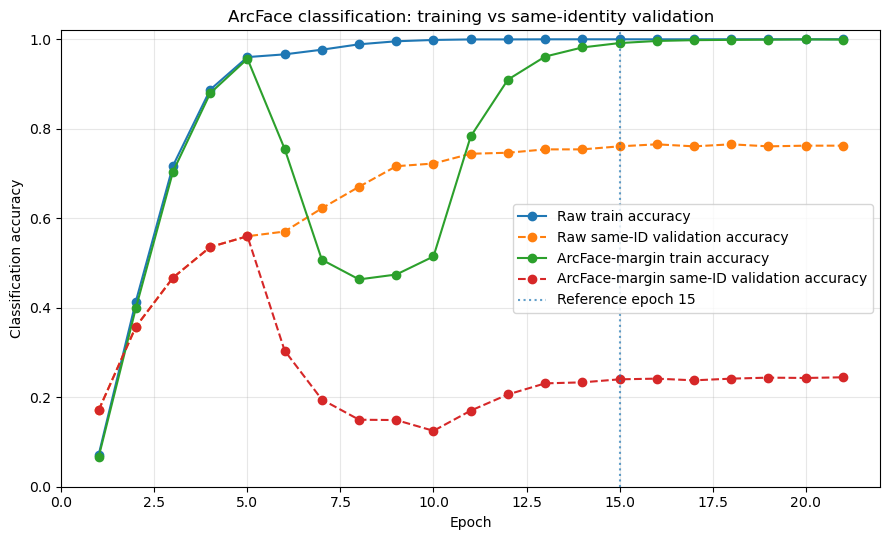

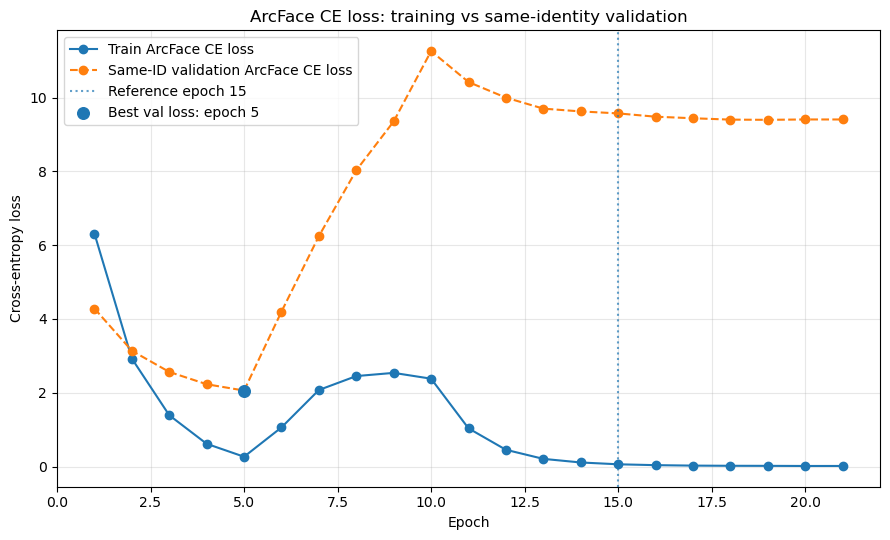

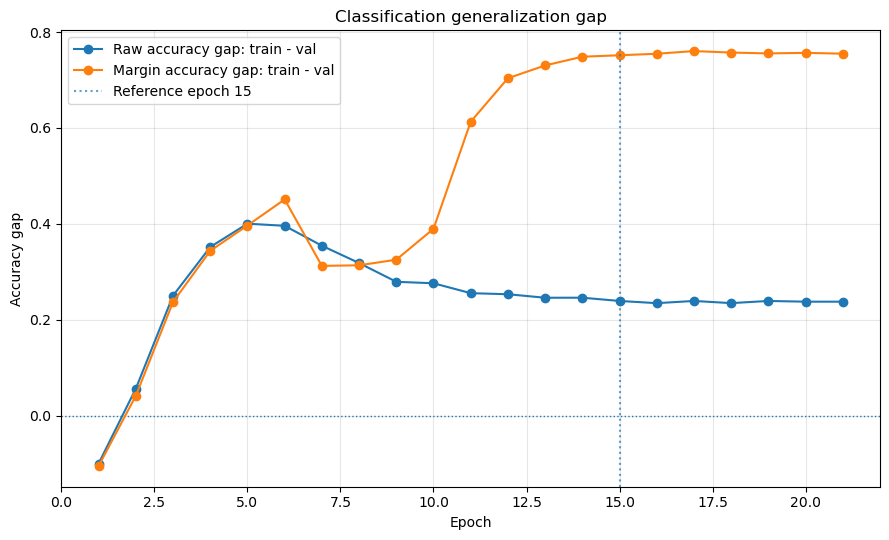

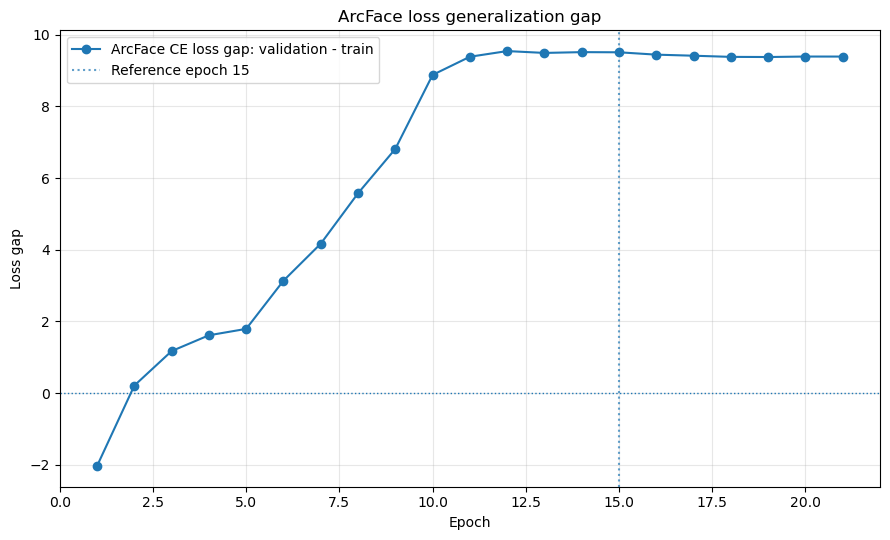

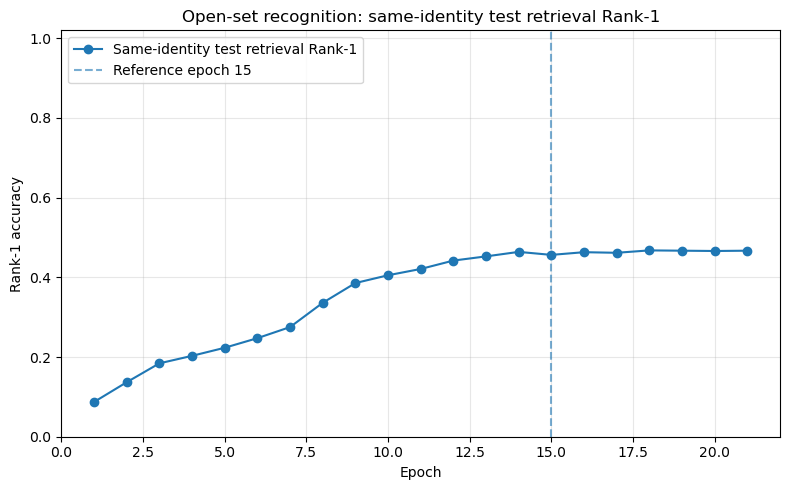

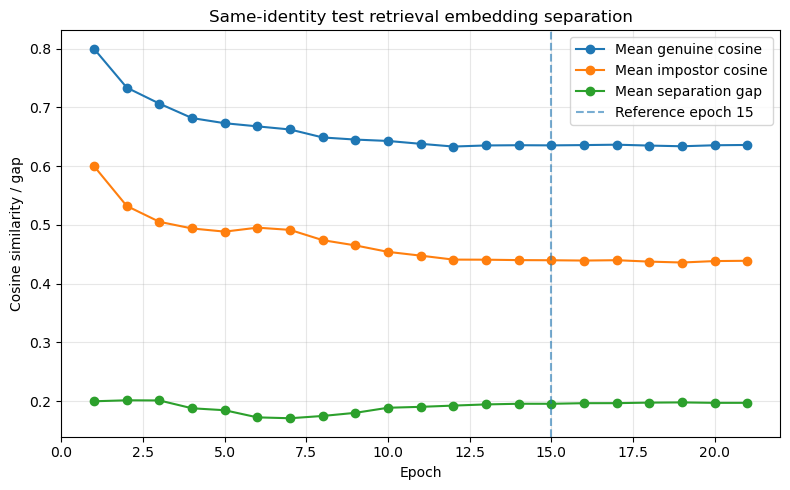

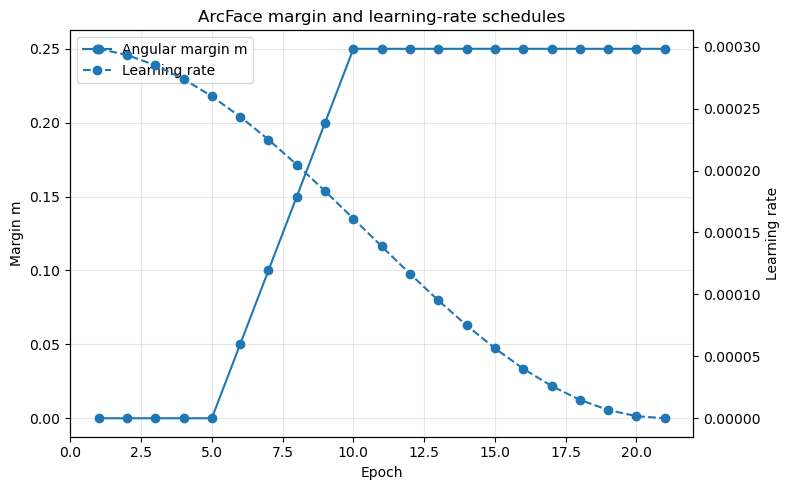

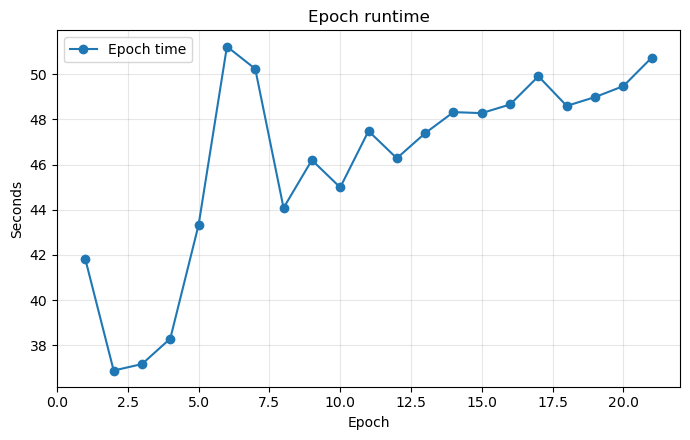


=== Selected epoch metrics ===
 epoch  margin  train_arcface_loss  sameid_val_arcface_loss  raw_train_acc  raw_sameid_val_acc  margin_train_acc  margin_sameid_val_acc  raw_acc_generalization_gap  margin_acc_generalization_gap  arcface_loss_generalization_gap  test_retrieval_rank1  test_retrieval_retrieval_error  test_retrieval_genuine_cos_mean  test_retrieval_impostor_cos_mean  test_retrieval_cosine_mean_gap       lr  epoch_time_sec
     5    0.00            0.264974                 2.058702       0.960214            0.559819          0.956371               0.559819                    0.400395                       0.396552                         1.793728              0.223308                        0.776692                         0.673122                          0.488560                        0.184562 0.000260       43.332348
    15    0.25            0.060224                 9.571655       1.000000            0.760722          0.991561               0.240030                    0

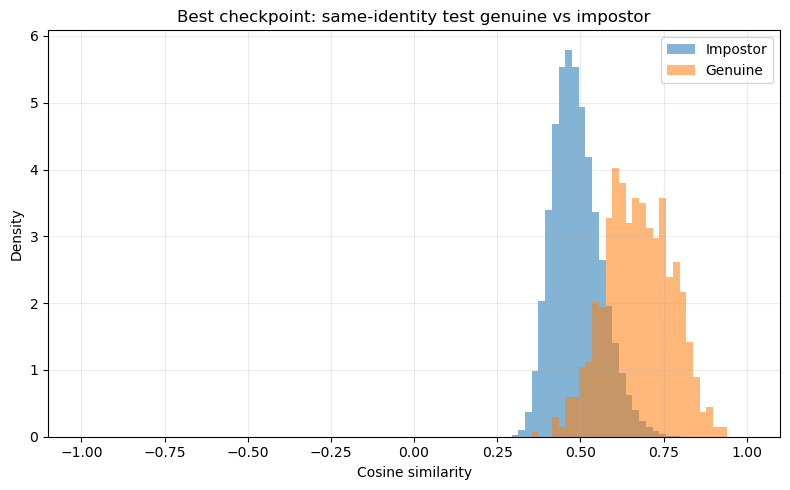

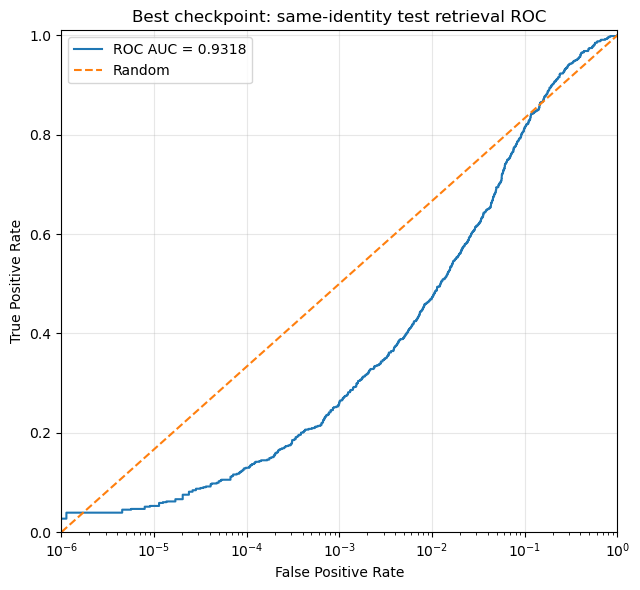


=== Best-checkpoint verification summary ===
 roc_auc      eer  eer_threshold  genuine_cos_mean  genuine_cos_std  impostor_cos_mean  impostor_cos_std  cosine_mean_gap
0.931831 0.144443       0.565398          0.673122         0.099252            0.48856          0.070916         0.184562

=== TPR at operational FPR points ===
        metric  target_FPR  actual_FPR      TPR  cosine_threshold
  TPR@FPR=0.01      0.0100    0.009999 0.472892          0.678410
 TPR@FPR=0.001      0.0010    0.000995 0.260542          0.744772
TPR@FPR=0.0001      0.0001    0.000097 0.129518          0.791361
[OK] saved: /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/0_align_block_for/out/celeba_wild_21k_frontend_v0_1/_recognition_runs/arcface_resnet18_legacyFall2025_sameidval_ep21_ref15_fr10_m0p25/same_identity_test_verification_metrics.csv
[OK] saved: /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/0_ali

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

history_path = RUN_DIR / "history.csv"
embeddings_path = RUN_DIR / "same_identity_test_retrieval_embeddings.npz"

assert history_path.exists()
assert embeddings_path.exists()

hist = pd.read_csv(history_path)
data = np.load(embeddings_path)

embeddings = data["embeddings"].astype(np.float32)
identity_ids = data["identity_id"].astype(str)

norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
embeddings = embeddings / np.clip(norms, 1e-12, None)

reference_present = REFERENCE_EPOCH in set(hist["epoch"].astype(int))

# ------------------------------------------------------------
# 1. Classification accuracy: train + honest same-ID validation
# ------------------------------------------------------------
plt.figure(figsize=(9, 5.5))
plt.plot(
    hist["epoch"], hist["raw_train_acc"], marker="o",
    label="Raw train accuracy"
)
plt.plot(
    hist["epoch"], hist["raw_sameid_val_acc"], marker="o", linestyle="--",
    label="Raw same-ID validation accuracy"
)
plt.plot(
    hist["epoch"], hist["margin_train_acc"], marker="o",
    label="ArcFace-margin train accuracy"
)
plt.plot(
    hist["epoch"], hist["margin_sameid_val_acc"], marker="o", linestyle="--",
    label="ArcFace-margin same-ID validation accuracy"
)

if reference_present:
    plt.axvline(
        REFERENCE_EPOCH,
        linestyle=":",
        alpha=0.7,
        label=f"Reference epoch {REFERENCE_EPOCH}",
    )

plt.xlabel("Epoch")
plt.ylabel("Classification accuracy")
plt.ylim(0.0, 1.02)
plt.title("ArcFace classification: training vs same-identity validation")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2. ArcFace CE loss: train + honest same-ID validation
# ------------------------------------------------------------
plt.figure(figsize=(9, 5.5))
plt.plot(
    hist["epoch"], hist["train_arcface_loss"], marker="o",
    label="Train ArcFace CE loss"
)
plt.plot(
    hist["epoch"], hist["sameid_val_arcface_loss"], marker="o", linestyle="--",
    label="Same-ID validation ArcFace CE loss"
)

if reference_present:
    plt.axvline(
        REFERENCE_EPOCH,
        linestyle=":",
        alpha=0.7,
        label=f"Reference epoch {REFERENCE_EPOCH}",
    )

best_hist_idx = hist["sameid_val_arcface_loss"].idxmin()
best_hist_epoch = int(hist.loc[best_hist_idx, "epoch"])
best_hist_loss = float(hist.loc[best_hist_idx, "sameid_val_arcface_loss"])

plt.scatter(
    [best_hist_epoch],
    [best_hist_loss],
    s=70,
    zorder=5,
    label=f"Best val loss: epoch {best_hist_epoch}",
)

plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("ArcFace CE loss: training vs same-identity validation")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3. Generalization gaps
# ------------------------------------------------------------
plt.figure(figsize=(9, 5.5))
plt.axhline(0.0, linewidth=1.0, linestyle=":")
plt.plot(
    hist["epoch"], hist["raw_acc_generalization_gap"], marker="o",
    label="Raw accuracy gap: train - val"
)
plt.plot(
    hist["epoch"], hist["margin_acc_generalization_gap"], marker="o",
    label="Margin accuracy gap: train - val"
)

if reference_present:
    plt.axvline(
        REFERENCE_EPOCH,
        linestyle=":",
        alpha=0.7,
        label=f"Reference epoch {REFERENCE_EPOCH}",
    )

plt.xlabel("Epoch")
plt.ylabel("Accuracy gap")
plt.title("Classification generalization gap")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5.5))
plt.axhline(0.0, linewidth=1.0, linestyle=":")
plt.plot(
    hist["epoch"], hist["arcface_loss_generalization_gap"], marker="o",
    label="ArcFace CE loss gap: validation - train"
)

if reference_present:
    plt.axvline(
        REFERENCE_EPOCH,
        linestyle=":",
        alpha=0.7,
        label=f"Reference epoch {REFERENCE_EPOCH}",
    )

plt.xlabel("Epoch")
plt.ylabel("Loss gap")
plt.title("ArcFace loss generalization gap")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. Original same-identity test retrieval Rank-1
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    hist["epoch"], hist["test_retrieval_rank1"], marker="o",
    label="Same-identity test retrieval Rank-1"
)

if reference_present:
    plt.axvline(
        REFERENCE_EPOCH,
        linestyle="--",
        alpha=0.6,
        label=f"Reference epoch {REFERENCE_EPOCH}",
    )

plt.xlabel("Epoch")
plt.ylabel("Rank-1 accuracy")
plt.ylim(0.0, 1.02)
plt.title("Open-set recognition: same-identity test retrieval Rank-1")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. Identity-disjoint embedding separation across epochs
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    hist["epoch"], hist["test_retrieval_genuine_cos_mean"], marker="o",
    label="Mean genuine cosine"
)
plt.plot(
    hist["epoch"], hist["test_retrieval_impostor_cos_mean"], marker="o",
    label="Mean impostor cosine"
)
plt.plot(
    hist["epoch"], hist["test_retrieval_cosine_mean_gap"], marker="o",
    label="Mean separation gap"
)

if reference_present:
    plt.axvline(
        REFERENCE_EPOCH,
        linestyle="--",
        alpha=0.6,
        label=f"Reference epoch {REFERENCE_EPOCH}",
    )

plt.xlabel("Epoch")
plt.ylabel("Cosine similarity / gap")
plt.title("Same-identity test retrieval embedding separation")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. Margin, LR, runtime
# ------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(8, 5))
line1 = ax1.plot(
    hist["epoch"], hist["margin"], marker="o",
    label="Angular margin m"
)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Margin m")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
line2 = ax2.plot(
    hist["epoch"], hist["lr"], marker="o", linestyle="--",
    label="Learning rate"
)
ax2.set_ylabel("Learning rate")

lines = line1 + line2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="best")
plt.title("ArcFace margin and learning-rate schedules")
fig.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.5))
plt.plot(
    hist["epoch"], hist["epoch_time_sec"], marker="o",
    label="Epoch time"
)
plt.xlabel("Epoch")
plt.ylabel("Seconds")
plt.title("Epoch runtime")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Numeric epoch summaries: reference, best by same-ID val loss, last
# ------------------------------------------------------------
summary_epochs = []

for ep in [
    REFERENCE_EPOCH,
    int(hist.loc[hist["sameid_val_arcface_loss"].idxmin(), "epoch"]),
    int(hist["epoch"].max()),
]:
    if ep in set(hist["epoch"].astype(int)) and ep not in summary_epochs:
        summary_epochs.append(ep)

metric_cols = [
    "epoch",
    "margin",
    "train_arcface_loss",
    "sameid_val_arcface_loss",
    "raw_train_acc",
    "raw_sameid_val_acc",
    "margin_train_acc",
    "margin_sameid_val_acc",
    "raw_acc_generalization_gap",
    "margin_acc_generalization_gap",
    "arcface_loss_generalization_gap",
    "test_retrieval_rank1",
    "test_retrieval_retrieval_error",
    "test_retrieval_genuine_cos_mean",
    "test_retrieval_impostor_cos_mean",
    "test_retrieval_cosine_mean_gap",
    "lr",
    "epoch_time_sec",
]

epoch_summary_df = hist.loc[
    hist["epoch"].isin(summary_epochs),
    metric_cols,
].copy()

epoch_summary_path = RUN_DIR / "selected_epoch_metrics.csv"
epoch_summary_df.to_csv(epoch_summary_path, index=False)

print("\n=== Selected epoch metrics ===")
print(epoch_summary_df.to_string(index=False))
print("[OK] saved:", epoch_summary_path)

# ------------------------------------------------------------
# Best-checkpoint genuine / impostor score distribution
# ------------------------------------------------------------
similarity = embeddings @ embeddings.T
n = len(identity_ids)
upper_i, upper_j = np.triu_indices(n, k=1)
scores = similarity[upper_i, upper_j]
same_identity = identity_ids[upper_i] == identity_ids[upper_j]

genuine_scores = scores[same_identity]
impostor_scores = scores[~same_identity]

print("\n=== Pair statistics at best checkpoint ===")
print("Genuine pairs :", len(genuine_scores))
print("Impostor pairs:", len(impostor_scores))
print(
    "Genuine cosine: mean={:.4f} median={:.4f} std={:.4f}".format(
        genuine_scores.mean(),
        np.median(genuine_scores),
        genuine_scores.std(),
    )
)
print(
    "Impostor cosine: mean={:.4f} median={:.4f} std={:.4f}".format(
        impostor_scores.mean(),
        np.median(impostor_scores),
        impostor_scores.std(),
    )
)
print(
    "Mean cosine separation gap: {:.4f}".format(
        genuine_scores.mean() - impostor_scores.mean()
    )
)

plt.figure(figsize=(8, 5))
bins = np.linspace(-1.0, 1.0, 100)
plt.hist(
    impostor_scores,
    bins=bins,
    density=True,
    alpha=0.55,
    label="Impostor",
)
plt.hist(
    genuine_scores,
    bins=bins,
    density=True,
    alpha=0.55,
    label="Genuine",
)
plt.xlabel("Cosine similarity")
plt.ylabel("Density")
plt.title("Best checkpoint: same-identity test genuine vs impostor")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# ROC / AUC / EER / TPR@FPR at the best checkpoint
# ------------------------------------------------------------
labels = same_identity.astype(np.int32)
fpr, tpr, thresholds = roc_curve(labels, scores)
roc_auc = roc_auc_score(labels, scores)

fnr = 1.0 - tpr
eer_idx = np.nanargmin(np.abs(fpr - fnr))
eer = float((fpr[eer_idx] + fnr[eer_idx]) / 2.0)
eer_threshold = float(thresholds[eer_idx])

plt.figure(figsize=(6.5, 6))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.4f}")
plt.plot(
    [1e-6, 1.0],
    [1e-6, 1.0],
    linestyle="--",
    label="Random",
)
plt.xscale("log")
plt.xlim(1e-6, 1.0)
plt.ylim(0.0, 1.01)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Best checkpoint: same-identity test retrieval ROC")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

rows = []

for target_fpr in [1e-2, 1e-3, 1e-4]:
    valid = np.where(fpr <= target_fpr)[0]

    if len(valid) == 0:
        row = {
            "metric": f"TPR@FPR={target_fpr:g}",
            "target_FPR": target_fpr,
            "actual_FPR": np.nan,
            "TPR": np.nan,
            "cosine_threshold": np.nan,
        }
    else:
        idx = valid[-1]
        row = {
            "metric": f"TPR@FPR={target_fpr:g}",
            "target_FPR": target_fpr,
            "actual_FPR": float(fpr[idx]),
            "TPR": float(tpr[idx]),
            "cosine_threshold": float(thresholds[idx]),
        }

    rows.append(row)

verification_df = pd.DataFrame(rows)
verification_path = RUN_DIR / "same_identity_test_verification_metrics.csv"
verification_df.to_csv(verification_path, index=False)

verification_summary = pd.DataFrame([{
    "roc_auc": float(roc_auc),
    "eer": eer,
    "eer_threshold": eer_threshold,
    "genuine_cos_mean": float(genuine_scores.mean()),
    "genuine_cos_std": float(genuine_scores.std()),
    "impostor_cos_mean": float(impostor_scores.mean()),
    "impostor_cos_std": float(impostor_scores.std()),
    "cosine_mean_gap": float(genuine_scores.mean() - impostor_scores.mean()),
}])

verification_summary_path = (
    RUN_DIR / "same_identity_test_verification_summary.csv"
)
verification_summary.to_csv(
    verification_summary_path,
    index=False,
)

print("\n=== Best-checkpoint verification summary ===")
print(verification_summary.to_string(index=False))

print("\n=== TPR at operational FPR points ===")
print(verification_df.to_string(index=False))

print("[OK] saved:", verification_path)
print("[OK] saved:", verification_summary_path)


## Cell 17 — Completion checkpoint

Expected run artifacts:

```text
best.pt
latest.pt
epoch_015_reference.pt

history.csv
history.json
reference_epoch15_metrics.csv
selected_epoch_metrics.csv
best_checkpoint_metrics.csv

identity_to_class.csv
same_identity_train_validation_manifest.csv
same_identity_split_summary.json

same_identity_test_retrieval_embeddings.npz
same_identity_test_verification_metrics.csv
same_identity_test_verification_summary.csv

config.json
environment.json
run_summary.json
```

### Metric semantics

**Same-identity classification validation**

- `train_arcface_loss` and `sameid_val_arcface_loss` are directly comparable ArcFace cross-entropy losses.
- `raw_train_acc` and `raw_sameid_val_acc` use normalized cosine classifier logits without angular margin.
- `margin_train_acc` and `margin_sameid_val_acc` use the ArcFace target-margin logits at that epoch.
- the validation images are held out from optimization but belong to the same 2087 classifier identities.

**Identity-disjoint recognition validation**

- `test_retrieval_rank1` is leave-one-out cosine Rank-1 over the original 500 unseen validation identities.
- genuine/impostor separation and verification metrics measure open-set embedding quality.
- these identities never appear in the ArcFace classifier head.

### Dataset integrity

The original dataset directories are not rewritten, copied, or moved. The same-identity split is a **manifest-defined virtual split** over the original `train` directory.

The frozen test split remains untouched.
